In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d salader/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/salader/dogs-vs-cats
License(s): unknown
100% 1.06G/1.06G [00:12<00:00, 253MB/s]
100% 1.06G/1.06G [00:12<00:00, 90.5MB/s]


In [7]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [8]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [9]:
# Generator
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [10]:
# Normalizing the Numpy arrays
def process(image,label):
  image = tf.cast(image/255. ,tf.float32)
  return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

# Why do we do Normalizing

#### 1.Scaling Pixel Values:
Image pixel values typically range from 0 to 255. Neural networks often perform better when input data is scaled to a smaller range, like 0 to 1. Dividing by 255 achieves this scaling.
#### 2.Data Type Conversion:
The original image data might be in an integer format. Neural networks usually work with floating-point numbers, so tf.cast converts the data to tf.float32.
#### 3.Improved Training:
Normalization helps the optimization algorithm (like gradient descent) converge faster and more effectively during training. It prevents features with larger values from dominating the learning process.

In [11]:
# create CNN model
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


This code defines a Convolutional Neural Network (CNN) model using Keras Sequential API. Let's break down the different parts:

*   **`model = Sequential()`**: This initializes a Sequential model, which is a linear stack of neural network layers.
*   **Convolutional and Pooling Layers (repeated 3 times)**:
    *   `model.add(Conv2D(..., activation='relu', ...))` : These are 2D convolutional layers. They apply filters to the input image to extract features. The number of filters increases from 32 to 64 and then to 128 in successive layers, allowing the network to learn increasingly complex patterns. The `relu` activation function introduces non-linearity.
    *   `model.add(MaxPooling2D(..., strides=2, ...))`: These are max pooling layers. They reduce the spatial dimensions (width and height) of the output from the convolutional layers. This helps to reduce the number of parameters and computations, and also makes the model more robust to small shifts or distortions in the input image. A stride of 2 means the pooling window moves two steps at a time.
*   **`model.add(Flatten())`**: This layer flattens the 3D output of the last pooling layer into a 1D vector. This is necessary because the subsequent dense layers expect a 1D input.
*   **Dense Layers**:
    *   `model.add(Dense(128, activation='relu'))`: This is a fully connected (dense) layer with 128 neurons and a `relu` activation function. It takes the flattened features as input and learns complex relationships between them.
    *   `model.add(Dropout(0.1))`: This is a dropout layer. During training, it randomly sets 10% of the input units to zero. This helps to prevent overfitting by making the model less reliant on specific neurons.
    *   `model.add(Dense(64, activation='relu'))`: Another dense layer with 64 neurons and a `relu` activation.
    *   `model.add(Dropout(0.1))`: Another dropout layer to further prevent overfitting.
    *   `model.add(Dense(1, activation='sigmoid'))`: This is the output layer. It has 1 neuron because this is a binary classification problem (dogs vs. cats). The `sigmoid` activation function outputs a value between 0 and 1, which can be interpreted as the probability of the input image belonging to the positive class (e.g., cat).

In summary, this CNN architecture progressively extracts features from the input images using convolutional and pooling layers, then flattens the features, and finally uses dense layers with dropout to perform the classification.

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [15]:
model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 73ms/step - accuracy: 0.5941 - loss: 0.6712 - val_accuracy: 0.7764 - val_loss: 0.4945
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 73ms/step - accuracy: 0.7724 - loss: 0.4794 - val_accuracy: 0.7888 - val_loss: 0.4562
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 78ms/step - accuracy: 0.8247 - loss: 0.3814 - val_accuracy: 0.8114 - val_loss: 0.4442
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.8912 - loss: 0.2587 - val_accuracy: 0.8112 - val_loss: 0.5457
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 0.9392 - loss: 0.1558 - val_accuracy: 0.8130 - val_loss: 0.7196
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 74ms/step - accuracy: 0.9571 - loss: 0.1086 - val_accuracy: 0.7956 - val_loss: 0.8165
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.9739 - loss: 0.0748 - val_accuracy: 0.8042 - val_loss: 0.8812
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.9834 - loss: 0.0472 - 

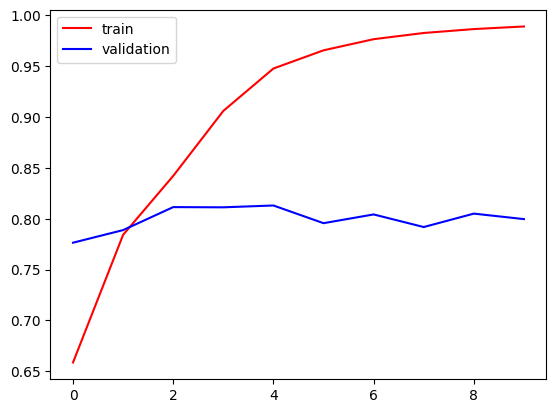

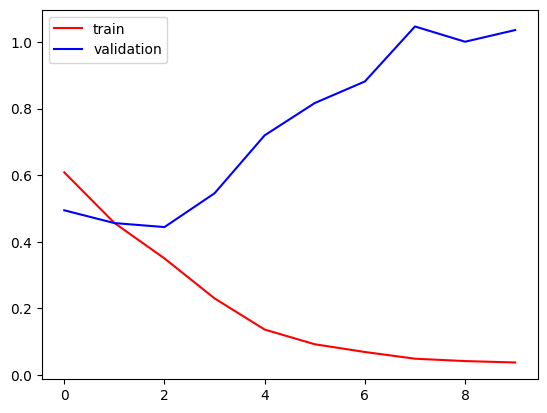

In [16]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(model.history.history['accuracy'],color='red',label='train')
plt.plot(model.history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(model.history.history['loss'],color='red',label='train')
plt.plot(model.history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

The training accuracy increases steadily and reaches a high value, indicating that the model is learning to classify the training data well. However, the validation accuracy plateaus and does not improve significantly after a few epochs.

Similarly, the training loss decreases consistently, while the validation loss starts to increase after a few epochs.

This pattern suggests that the model is overfitting to the training data. It is learning the training examples too well, including the noise, and is not generalizing well to unseen data (the validation set).


## Reducing Overfitting


### Batch Normalization

Batch Normalization is a technique used to improve the training of deep neural networks. It involves normalizing the inputs to each layer within a mini-batch. This means that for each feature in the input, Batch Normalization calculates the mean and variance across the current mini-batch and then normalizes the feature using these statistics.

Here's why Batch Normalization is beneficial:

Reduces Internal Covariate Shift: Internal Covariate Shift refers to the change in the distribution of network activations due to the change in network parameters during training. This can slow down the training process and make it harder for the network to converge. Batch Normalization helps to stabilize these distributions, allowing for faster and more stable training.
Allows for higher learning rates: By reducing internal covariate shift, Batch Normalization allows you to use higher learning rates, which can further speed up the training process.


In [14]:
# create CNN model
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [16]:
model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 83ms/step - accuracy: 0.5498 - loss: 2.6074 - val_accuracy: 0.5824 - val_loss: 1.2613
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.6568 - loss: 0.6461 - val_accuracy: 0.6534 - val_loss: 0.6254
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.7296 - loss: 0.5436 - val_accuracy: 0.7116 - val_loss: 0.5665
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.7704 - loss: 0.4911 - val_accuracy: 0.7280 - val_loss: 0.5511
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.8138 - loss: 0.4126 - val_accuracy: 0.7972 - val_loss: 0.4510
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 84ms/step - accuracy: 0.8483 - loss: 0.3434 - val_accuracy: 0.7836 - val_loss: 0.5338
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.8874 - loss: 0.2714 - val_accuracy: 0.7878 - val_loss: 0.4960
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.9140 - loss: 0.2071 - 

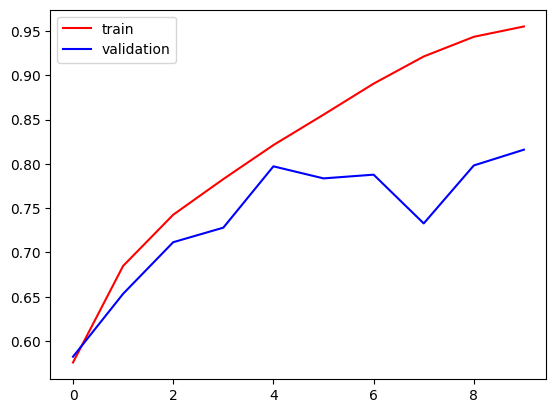

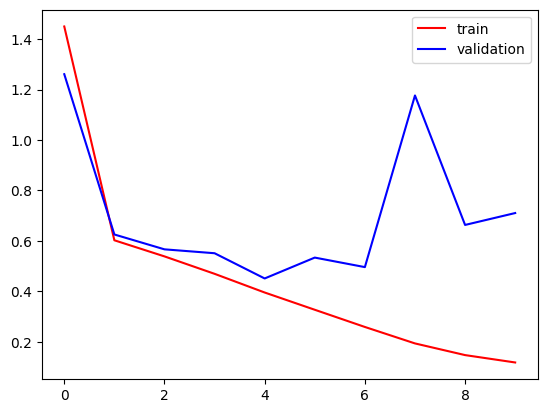

In [17]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(model.history.history['accuracy'],color='red',label='train')
plt.plot(model.history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(model.history.history['loss'],color='red',label='train')
plt.plot(model.history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()